Phase 2

In [ ]:
# ── SETUP VISUALIZATION LIBRARIES ──────────────────────────────────────
import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── SETUP PATHS ────────────────────────────────────────────────────────────────
os.chdir("/Users/animesh/Documents/personal_git/melbourne-crime-liveability-dashboard")
PROCESSED = "data/processed/"
SQL_OUTPUT = "sql/"
VIZ_OUTPUT = "sql/visualizations/"  # New folder for charts
os.makedirs(VIZ_OUTPUT, exist_ok=True)

# Set style for beautiful charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("✅ Visualization libraries loaded!")
print(f"✅ Charts will be saved to: {VIZ_OUTPUT}")


✅ Visualization libraries loaded!
✅ Charts will be saved to: sql/visualizations/


In [13]:
# ==================================================================================
# ──  SETUP - LOAD DATA INTO SQLITE DATABASE ────────────────────────────
# ==================================================================================

print("\n" + "="*60)
print("📊 PHASE 2: SQL ANALYSIS")
print("="*60)
print("\nStep 1: Creating SQLite database...\n")

# ── CREATE DATABASE CONNECTION ────────────────────────────────────────────────
# This creates a file called 'crime_data.db' in our project
db_path = "crime_data.db"
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

print(f"✓ Database created: {db_path}")
# ── LOAD CLEANED CSV INTO DATABASE ────────────────────────────────────────────
print("\nStep 2: Loading cleaned data into database table...\n")

# Read the CSV we created in Phase 1
crime_df = pd.read_csv(PROCESSED + "crime_clean.csv")

print(f"✓ Loaded {len(crime_df)} rows from CSV")
print(f"✓ Columns: {crime_df.columns.tolist()}")

# Write the data to SQLite as a table called 'crimes'
crime_df.to_sql('crimes', conn, if_exists='replace', index=False)

print(f"✓ Created table 'crimes' in database")

# ── VERIFY TABLE WAS CREATED ──────────────────────────────────────────────────
print("\nStep 3: Verifying table...\n")

# Check how many rows in the table
cursor.execute("SELECT COUNT(*) FROM crimes")
row_count = cursor.fetchone()[0]
print(f"✓ Total rows in 'crimes' table: {row_count}")

# Show the structure of the table
cursor.execute("PRAGMA table_info(crimes)")
columns = cursor.fetchall()
print(f"✓ Table columns:")
for col in columns:
    col_name, col_type = col[1], col[2]
    print(f"   - {col_name}: {col_type}")

# Show first few rows
print(f"\n✓ First 5 rows of data:")
cursor.execute("SELECT * FROM crimes LIMIT 5")
rows = cursor.fetchall()
for row in rows:
    print(f"   {row}")

print(f"\n✅ Database setup complete!")
print(f"✅ Ready to run SQL queries!")


📊 PHASE 2: SQL ANALYSIS

Step 1: Creating SQLite database...

✓ Database created: crime_data.db

Step 2: Loading cleaned data into database table...

✓ Loaded 290 rows from CSV
✓ Columns: ['year', 'year_ending', 'police_region', 'lga_name', 'incidents', 'rate_per_100k']
✓ Created table 'crimes' in database

Step 3: Verifying table...

✓ Total rows in 'crimes' table: 290
✓ Table columns:
   - year: INTEGER
   - year_ending: TEXT
   - police_region: TEXT
   - lga_name: TEXT
   - incidents: INTEGER
   - rate_per_100k: REAL

✓ First 5 rows of data:
   (2024, 'December', '1 North West Metro', 'BANYULE', 7590, 5702.17011683)
   (2024, 'December', '1 North West Metro', 'BRIMBANK', 14119, 7124.608799554)
   (2024, 'December', '1 North West Metro', 'DAREBIN', 13982, 8771.785831693)
   (2024, 'December', '1 North West Metro', 'HOBSONS BAY', 5973, 6293.377882117)
   (2024, 'December', '1 North West Metro', 'HUME', 16427, 6074.756225679)

✅ Database setup complete!
✅ Ready to run SQL queries!



QUERY 1: CRIME TREND BY LGA AND YEAR

SQL Query:

SELECT 
    year,
    lga_name,
    SUM(incidents) as total_incidents,
    ROUND(AVG(rate_per_100k), 2) as avg_crime_rate
FROM crimes
GROUP BY year, lga_name
ORDER BY year DESC, total_incidents DESC


What this does:
- SUM(incidents): Adds up all incidents for that LGA in that year
- AVG(rate_per_100k): Calculates average crime rate
- GROUP BY: Groups results by year and LGA
- ORDER BY: Sorts by newest year first, then by most incidents

Results Preview (first 20 rows):
    year              lga_name  total_incidents  avg_crime_rate
0   2024             MELBOURNE            32840        16965.34
1   2024                 CASEY            20421         5071.47
2   2024               WYNDHAM            17819         5294.88
3   2024                  HUME            16427         6074.76
4   2024     GREATER DANDENONG            16171         9704.40
5   2024              BRIMBANK            14119         7124.61
6   2024               DAR

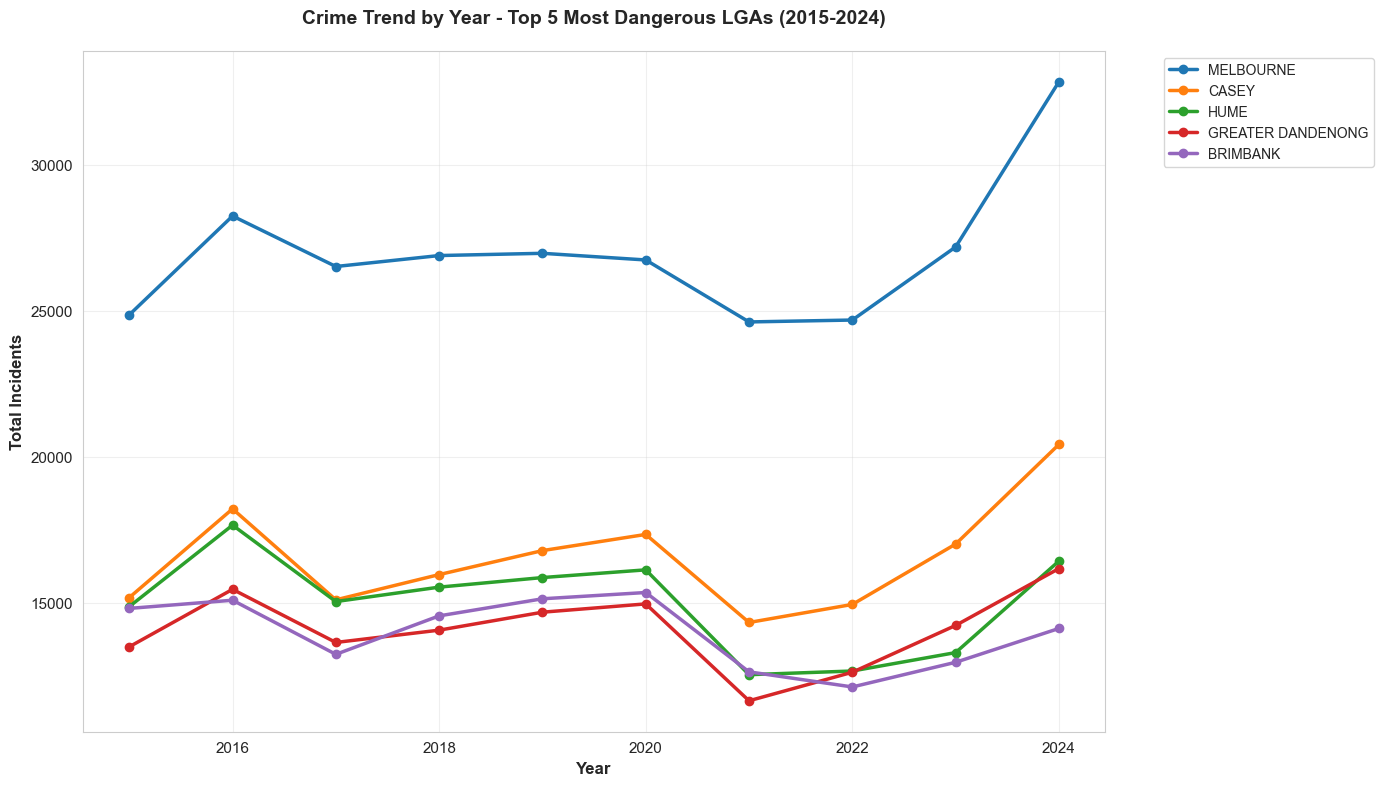


✓ What this shows:
  - Lines show incident trends over 10 years
  - Top 5 most dangerous LGAs plotted
  - You can see if crime is going up or down


In [14]:
# ==================================================================================
# ── CELL 2: QUERY 1 - CRIME TREND BY LGA AND YEAR ────────────────────────────
# ==================================================================================

print("\n" + "="*60)
print("QUERY 1: CRIME TREND BY LGA AND YEAR")
print("="*60)
print("\nSQL Query:")
print("""
SELECT 
    year,
    lga_name,
    SUM(incidents) as total_incidents,
    ROUND(AVG(rate_per_100k), 2) as avg_crime_rate
FROM crimes
GROUP BY year, lga_name
ORDER BY year DESC, total_incidents DESC
""")

print("\nWhat this does:")
print("- SUM(incidents): Adds up all incidents for that LGA in that year")
print("- AVG(rate_per_100k): Calculates average crime rate")
print("- GROUP BY: Groups results by year and LGA")
print("- ORDER BY: Sorts by newest year first, then by most incidents\n")

# ── RUN THE QUERY ─────────────────────────────────────────────────────────────
query1 = """
SELECT 
    year,
    lga_name,
    SUM(incidents) as total_incidents,
    ROUND(AVG(rate_per_100k), 2) as avg_crime_rate
FROM crimes
GROUP BY year, lga_name
ORDER BY year DESC, total_incidents DESC
"""
df_query1 = pd.read_sql_query(query1, conn)

print("Results Preview (first 20 rows):")
print(df_query1.head(20))

print(f"\nTotal rows returned: {len(df_query1)}")

# Export to CSV
output_file1 = SQL_OUTPUT + "01_trend_by_lga_year.csv"
df_query1.to_csv(output_file1, index=False)
print(f"\n✓ Exported to: {output_file1}")

print("\n" + "="*60)
print("VISUALIZATION: Crime Trend Over Time (Top 5 LGAs)")
print("="*60)

# Filter to top 5 LGAs by total incidents
top5_lgas = df_query1.groupby('lga_name')['total_incidents'].sum().nlargest(5).index
trend_data = df_query1[df_query1['lga_name'].isin(top5_lgas)]

# Create figure
plt.figure(figsize=(14, 8))

# Plot a line for each LGA
for lga in top5_lgas:
    lga_data = trend_data[trend_data['lga_name'] == lga].sort_values('year')
    plt.plot(lga_data['year'], lga_data['total_incidents'], 
             marker='o', linewidth=2.5, markersize=6, label=lga)

plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Total Incidents', fontsize=12, fontweight='bold')
plt.title('Crime Trend by Year - Top 5 Most Dangerous LGAs (2015-2024)', 
          fontsize=14, fontweight='bold', pad=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the chart
chart_path = VIZ_OUTPUT + "01_crime_trend_top5_lgas.png"
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Chart saved: {chart_path}")

plt.show()

print("\n✓ What this shows:")
print("  - Lines show incident trends over 10 years")
print("  - Top 5 most dangerous LGAs plotted")
print("  - You can see if crime is going up or down")


QUERY 2: TOP 10 HIGHEST CRIME LGAs

SQL Query:

SELECT 
    lga_name,
    SUM(incidents) as total_incidents,
    COUNT(DISTINCT year) as years_of_data,
    ROUND(AVG(rate_per_100k), 2) as avg_crime_rate,
    ROUND(MAX(rate_per_100k), 2) as max_crime_rate
FROM crimes
GROUP BY lga_name
ORDER BY total_incidents DESC
LIMIT 10


What this does:
- Calculates TOTAL incidents for each LGA (summed across all years)
- Shows how many years of data we have
- Shows average and maximum crime rates
- LIMIT 10: Only show top 10 LGAs

Results (Top 10 Highest Crime LGAs):
         lga_name  total_incidents  years_of_data  avg_crime_rate  max_crime_rate
        MELBOURNE           269519             10        16634.30        19331.12
            CASEY           165273             10         4701.71         5823.09
             HUME           150004             10         6444.27         8528.26
GREATER DANDENONG           140944             10         8663.16         9704.40
         BRIMBANK           

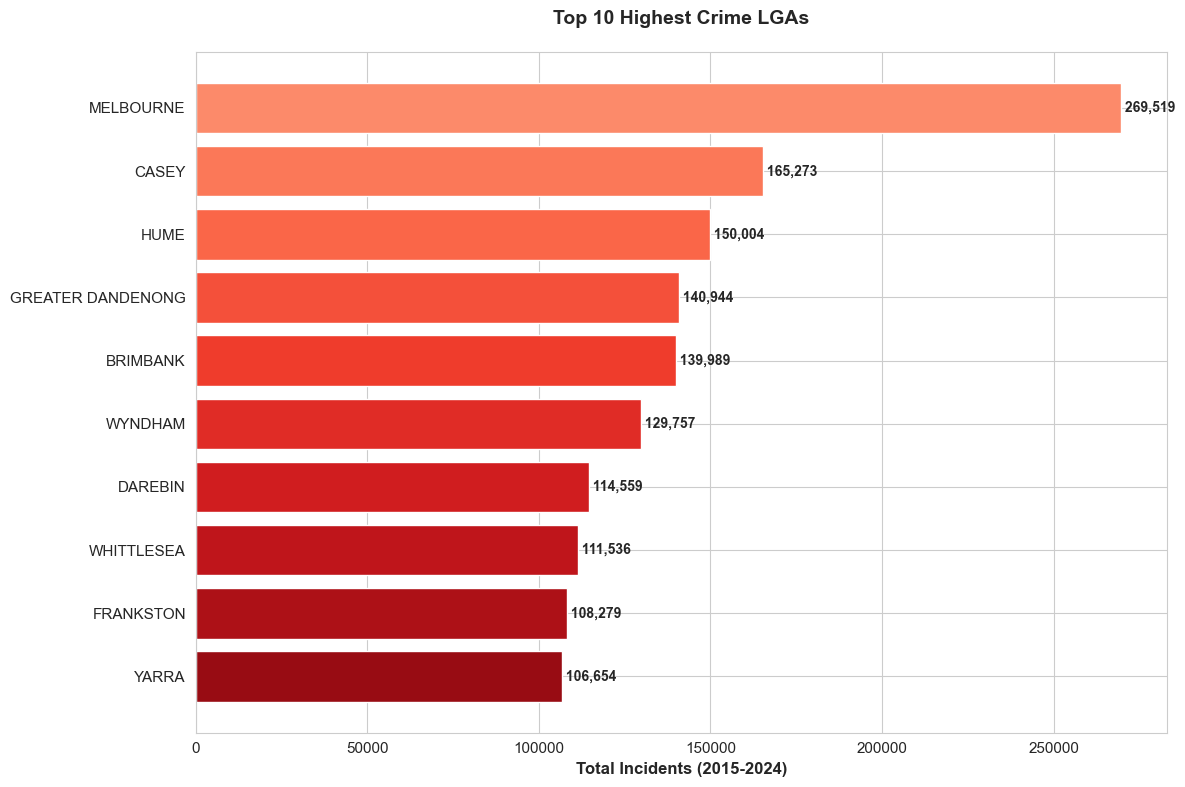


✓ What this shows:
  - Melbourne is the most dangerous (far right)
  - Hume and Brimbank are also high
  - Darker red = more dangerous


In [17]:
# ==================================================================================
# ── QUERY 2 - TOP 10 HIGHEST CRIME LGAs ──────────────────────────────
# ==================================================================================

print("\n" + "="*60)
print("QUERY 2: TOP 10 HIGHEST CRIME LGAs")
print("="*60)
print("\nSQL Query:")
print("""
SELECT 
    lga_name,
    SUM(incidents) as total_incidents,
    COUNT(DISTINCT year) as years_of_data,
    ROUND(AVG(rate_per_100k), 2) as avg_crime_rate,
    ROUND(MAX(rate_per_100k), 2) as max_crime_rate
FROM crimes
GROUP BY lga_name
ORDER BY total_incidents DESC
LIMIT 10
""")

print("\nWhat this does:")
print("- Calculates TOTAL incidents for each LGA (summed across all years)")
print("- Shows how many years of data we have")
print("- Shows average and maximum crime rates")
print("- LIMIT 10: Only show top 10 LGAs\n")

# ── RUN THE QUERY ─────────────────────────────────────────────────────────────
query2 = """
SELECT 
    lga_name,
    SUM(incidents) as total_incidents,
    COUNT(DISTINCT year) as years_of_data,
    ROUND(AVG(rate_per_100k), 2) as avg_crime_rate,
    ROUND(MAX(rate_per_100k), 2) as max_crime_rate
FROM crimes
GROUP BY lga_name
ORDER BY total_incidents DESC
LIMIT 10
"""

df_query2 = pd.read_sql_query(query2, conn)

print("Results (Top 10 Highest Crime LGAs):")
print(df_query2.to_string(index=False))

# Export to CSV
output_file2 = SQL_OUTPUT + "02_top10_highest_crime.csv"
df_query2.to_csv(output_file2, index=False)
print(f"\n✓ Exported to: {output_file2}")

print("\n" + "="*60)
print("VISUALIZATION: Top 10 Highest Crime LGAs")
print("="*60)

# Create figure
plt.figure(figsize=(12, 8))

# Horizontal bar chart (easier to read LGA names)
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(df_query2)))
plt.barh(df_query2['lga_name'], df_query2['total_incidents'], color=colors)

plt.xlabel('Total Incidents (2015-2024)', fontsize=12, fontweight='bold')
plt.title('Top 10 Highest Crime LGAs', fontsize=14, fontweight='bold', pad=20)
plt.gca().invert_yaxis()  # Highest at top

# Add value labels on bars
for i, (idx, row) in enumerate(df_query2.iterrows()):
    plt.text(row['total_incidents'], i, f" {row['total_incidents']:,.0f}", 
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()

# Save the chart
chart_path = VIZ_OUTPUT + "02_top10_highest_crime.png"
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Chart saved: {chart_path}")

plt.show()

print("\n✓ What this shows:")
print("  - Melbourne is the most dangerous (far right)")
print("  - Hume and Brimbank are also high")
print("  - Darker red = more dangerous")


In [18]:
# ==================================================================================
# ── QUERY 3 - TOP 10 SAFEST LGAs ────────────────────────────────────
# ==================================================================================

print("\n" + "="*60)
print("QUERY 3: TOP 10 SAFEST LGAs")
print("="*60)
print("\nSQL Query:")
print("""
SELECT 
    lga_name,
    SUM(incidents) as total_incidents,
    COUNT(DISTINCT year) as years_of_data,
    ROUND(AVG(rate_per_100k), 2) as avg_crime_rate,
    ROUND(MIN(rate_per_100k), 2) as min_crime_rate
FROM crimes
GROUP BY lga_name
ORDER BY total_incidents ASC
LIMIT 10
""")

print("\nWhat this does:")
print("- Calculates TOTAL incidents for each LGA")
print("- Shows minimum crime rate (lowest point)")
print("- ORDER BY total_incidents ASC: Sorts from LEAST to MOST")
print("- LIMIT 10: Show top 10 safest LGAs\n")

# ── RUN THE QUERY ─────────────────────────────────────────────────────────────
query3 = """
SELECT 
    lga_name,
    SUM(incidents) as total_incidents,
    COUNT(DISTINCT year) as years_of_data,
    ROUND(AVG(rate_per_100k), 2) as avg_crime_rate,
    ROUND(MIN(rate_per_100k), 2) as min_crime_rate
FROM crimes
GROUP BY lga_name
ORDER BY total_incidents ASC
LIMIT 10
"""

df_query3 = pd.read_sql_query(query3, conn)

print("Results (Top 10 Safest LGAs):")
print(df_query3.to_string(index=False))

# Export to CSV
output_file3 = SQL_OUTPUT + "03_top10_safest.csv"
df_query3.to_csv(output_file3, index=False)
print(f"\n✓ Exported to: {output_file3}")



QUERY 3: TOP 10 SAFEST LGAs

SQL Query:

SELECT 
    lga_name,
    SUM(incidents) as total_incidents,
    COUNT(DISTINCT year) as years_of_data,
    ROUND(AVG(rate_per_100k), 2) as avg_crime_rate,
    ROUND(MIN(rate_per_100k), 2) as min_crime_rate
FROM crimes
GROUP BY lga_name
ORDER BY total_incidents ASC
LIMIT 10


What this does:
- Calculates TOTAL incidents for each LGA
- Shows minimum crime rate (lowest point)
- ORDER BY total_incidents ASC: Sorts from LEAST to MOST
- LIMIT 10: Show top 10 safest LGAs

Results (Top 10 Safest LGAs):
    lga_name  total_incidents  years_of_data  avg_crime_rate  min_crime_rate
   NILLUMBIK            16462             10         2575.42         1866.30
  MANNINGHAM            35213             10         2791.87         2249.35
     BAYSIDE            39199             10         3770.88         3246.42
 HOBSONS BAY            49636             10         5288.89         4712.53
    CARDINIA            50206             10         4484.73         358


VISUALIZATION: Top 10 Safest LGAs

✓ Chart saved: sql/visualizations/03_top10_safest.png


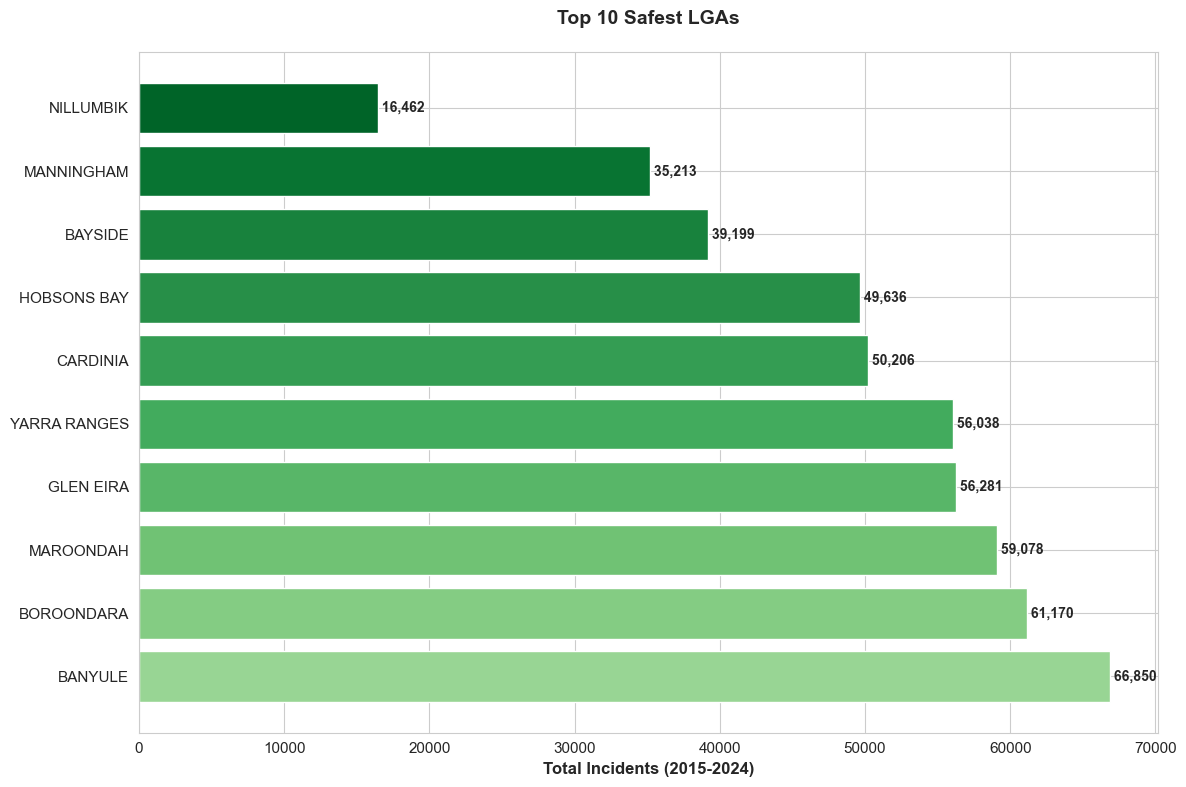


✓ What this shows:
  - Nillumbik is the safest (lowest incidents)
  - Cardinia and Mornington Peninsula also safe
  - Darker green = safer


In [19]:
# ==================================================================================
# ──  VISUALIZATION FOR QUERY 3 ──────────────────────────────────────
# ==================================================================================

print("\n" + "="*60)
print("VISUALIZATION: Top 10 Safest LGAs")
print("="*60)

# Create figure
plt.figure(figsize=(12, 8))

# Horizontal bar chart (green = safe)
colors = plt.cm.Greens(np.linspace(0.9, 0.4, len(df_query3)))
plt.barh(df_query3['lga_name'], df_query3['total_incidents'], color=colors)

plt.xlabel('Total Incidents (2015-2024)', fontsize=12, fontweight='bold')
plt.title('Top 10 Safest LGAs', fontsize=14, fontweight='bold', pad=20)
plt.gca().invert_yaxis()  # Safest at top

# Add value labels on bars
for i, (idx, row) in enumerate(df_query3.iterrows()):
    plt.text(row['total_incidents'], i, f" {row['total_incidents']:,.0f}", 
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()

# Save the chart
chart_path = VIZ_OUTPUT + "03_top10_safest.png"
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Chart saved: {chart_path}")

plt.show()

print("\n✓ What this shows:")
print("  - Nillumbik is the safest (lowest incidents)")
print("  - Cardinia and Mornington Peninsula also safe")
print("  - Darker green = safer")



QUERY 4: CRIME COMPARISON 2015 vs 2024

SQL Query:

SELECT 
    lga_name,
    MAX(CASE WHEN year = 2015 THEN incidents END) as incidents_2015,
    MAX(CASE WHEN year = 2024 THEN incidents END) as incidents_2024,
    MAX(CASE WHEN year = 2024 THEN incidents END) - 
    MAX(CASE WHEN year = 2015 THEN incidents END) as change,
    ROUND(((MAX(CASE WHEN year = 2024 THEN incidents END) - 
            MAX(CASE WHEN year = 2015 THEN incidents END)) / 
           MAX(CASE WHEN year = 2015 THEN incidents END)) * 100, 2) as pct_change
FROM crimes
WHERE year IN (2015, 2024)
GROUP BY lga_name
ORDER BY pct_change DESC


What this does:
- CASE WHEN: Extracts data for 2015 and 2024 separately
- change: Difference between 2024 and 2015 (positive = more crime)
- pct_change: Percentage change year-over-year
- ORDER BY pct_change DESC: Worst to best

Results (Crime Change 2015 vs 2024):
            lga_name  incidents_2015  incidents_2024  change  pct_change
        YARRA RANGES            5442         

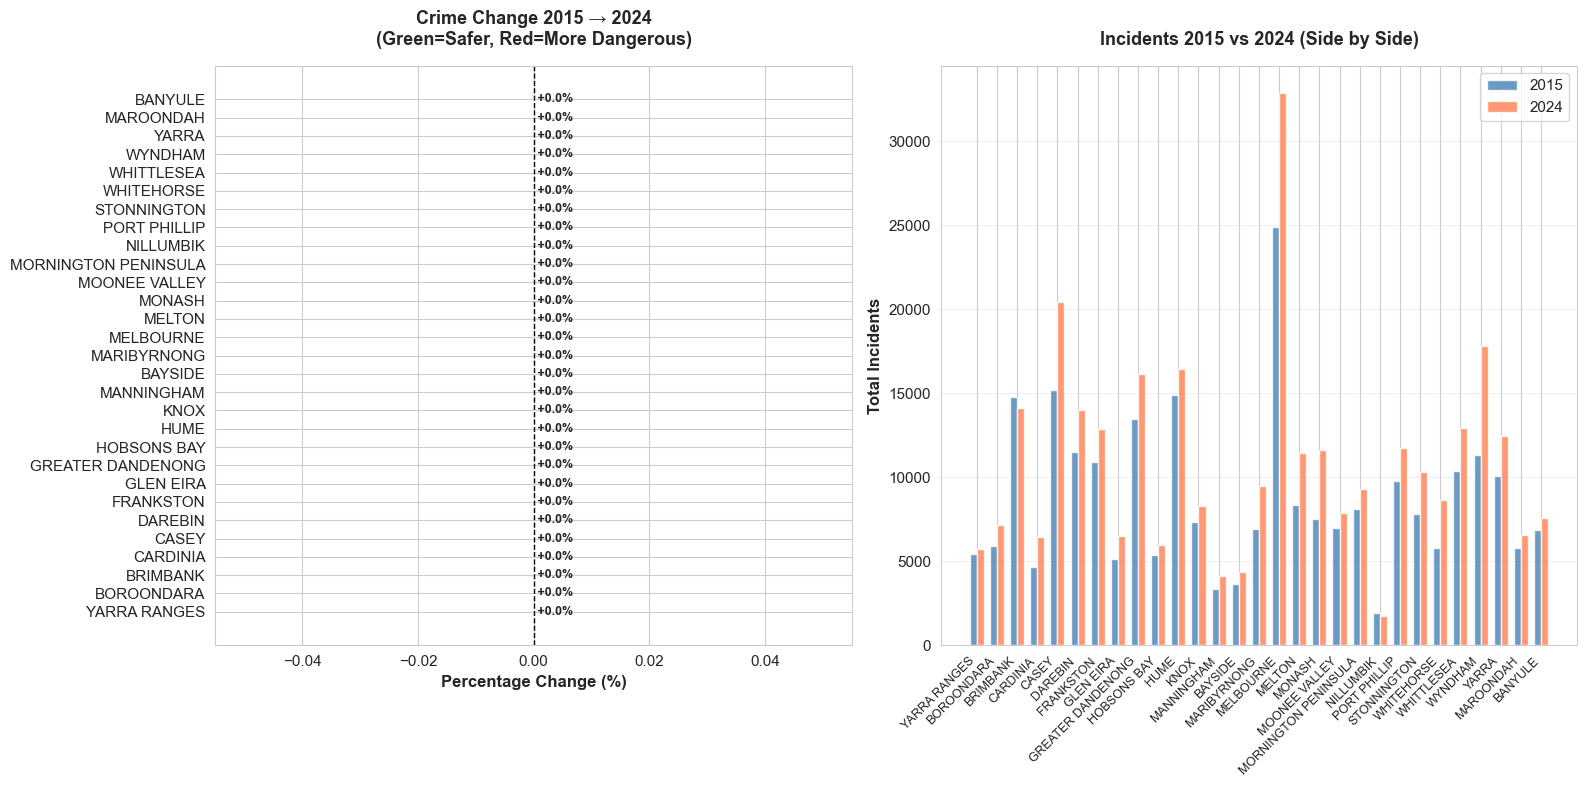


✓ What this shows:
  - Left chart: % change (green=safer, red=more dangerous)
  - Right chart: Side-by-side comparison of 2015 vs 2024
  - Most LGAs got MORE dangerous (positive %)


In [21]:
# ==================================================================================
# ──  QUERY 4 - CRIME COMPARISON 2015 vs 2024 ─────────────────────────
# ==================================================================================

print("\n" + "="*60)
print("QUERY 4: CRIME COMPARISON 2015 vs 2024")
print("="*60)
print("\nSQL Query:")
print("""
SELECT 
    lga_name,
    MAX(CASE WHEN year = 2015 THEN incidents END) as incidents_2015,
    MAX(CASE WHEN year = 2024 THEN incidents END) as incidents_2024,
    MAX(CASE WHEN year = 2024 THEN incidents END) - 
    MAX(CASE WHEN year = 2015 THEN incidents END) as change,
    ROUND(((MAX(CASE WHEN year = 2024 THEN incidents END) - 
            MAX(CASE WHEN year = 2015 THEN incidents END)) / 
           MAX(CASE WHEN year = 2015 THEN incidents END)) * 100, 2) as pct_change
FROM crimes
WHERE year IN (2015, 2024)
GROUP BY lga_name
ORDER BY pct_change DESC
""")

print("\nWhat this does:")
print("- CASE WHEN: Extracts data for 2015 and 2024 separately")
print("- change: Difference between 2024 and 2015 (positive = more crime)")
print("- pct_change: Percentage change year-over-year")
print("- ORDER BY pct_change DESC: Worst to best\n")
# ── RUN THE QUERY ─────────────────────────────────────────────────────────────
query4 = """
SELECT 
    lga_name,
    MAX(CASE WHEN year = 2015 THEN incidents END) as incidents_2015,
    MAX(CASE WHEN year = 2024 THEN incidents END) as incidents_2024,
    MAX(CASE WHEN year = 2024 THEN incidents END) - 
    MAX(CASE WHEN year = 2015 THEN incidents END) as change,
    ROUND(((MAX(CASE WHEN year = 2024 THEN incidents END) - 
            MAX(CASE WHEN year = 2015 THEN incidents END)) / 
           MAX(CASE WHEN year = 2015 THEN incidents END)) * 100, 2) as pct_change
FROM crimes
WHERE year IN (2015, 2024)
GROUP BY lga_name
ORDER BY pct_change DESC
"""

df_query4 = pd.read_sql_query(query4, conn)

print("Results (Crime Change 2015 vs 2024):")
print(df_query4.to_string(index=False))

print(f"\n✓ Positive change = More crime in 2024")
print(f"✓ Negative change = Less crime in 2024 (safer)")

# Export to CSV
output_file4 = SQL_OUTPUT + "04_2015_vs_2024_comparison.csv"
df_query4.to_csv(output_file4, index=False)
print(f"\n✓ Exported to: {output_file4}")
print("\n" + "="*60)
print("VISUALIZATION: 2015 vs 2024 Crime Comparison")
print("="*60)

# Prepare data
comparison_data = df_query4.sort_values('pct_change', ascending=True)

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# ── SUBPLOT 1: Percentage Change (which got worse/better) ──
colors_change = ['green' if x < 0 else 'red' for x in comparison_data['pct_change']]
ax1.barh(comparison_data['lga_name'], comparison_data['pct_change'], color=colors_change)
ax1.set_xlabel('Percentage Change (%)', fontsize=12, fontweight='bold')
ax1.set_title('Crime Change 2015 → 2024\n(Green=Safer, Red=More Dangerous)', 
              fontsize=13, fontweight='bold', pad=15)
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)

# Add value labels
for i, (idx, row) in enumerate(comparison_data.iterrows()):
    ax1.text(row['pct_change'], i, f" {row['pct_change']:+.1f}%", 
             va='center', fontsize=9, fontweight='bold')

# ── SUBPLOT 2: Incident Comparison (bars side by side) ──
x = np.arange(len(comparison_data))
width = 0.35

ax2.bar(x - width/2, comparison_data['incidents_2015'], width, 
        label='2015', alpha=0.8, color='steelblue')
ax2.bar(x + width/2, comparison_data['incidents_2024'], width, 
        label='2024', alpha=0.8, color='coral')

ax2.set_ylabel('Total Incidents', fontsize=12, fontweight='bold')
ax2.set_title('Incidents 2015 vs 2024 (Side by Side)', fontsize=13, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(comparison_data['lga_name'], rotation=45, ha='right', fontsize=9)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

# Save the chart
chart_path = VIZ_OUTPUT + "04_2015_vs_2024_comparison.png"
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Chart saved: {chart_path}")

plt.show()

print("\n✓ What this shows:")
print("  - Left chart: % change (green=safer, red=more dangerous)")
print("  - Right chart: Side-by-side comparison of 2015 vs 2024")
print("  - Most LGAs got MORE dangerous (positive %)")



In [22]:
# ==================================================================================
# ──  QUERY 5 - MELBOURNE-WIDE ANNUAL CRIME RATE TREND ─────────────────
# ==================================================================================

print("\n" + "="*60)
print("QUERY 5: MELBOURNE-WIDE ANNUAL CRIME RATE TREND")
print("="*60)
print("\nSQL Query:")
print("""
SELECT 
    year,
    SUM(incidents) as total_incidents,
    COUNT(DISTINCT lga_name) as num_lgas,
    ROUND(AVG(rate_per_100k), 2) as avg_crime_rate,
    ROUND(MIN(rate_per_100k), 2) as safest_lga_rate,
    ROUND(MAX(rate_per_100k), 2) as highest_crime_rate
FROM crimes
GROUP BY year
ORDER BY year ASC
""")

print("\nWhat this does:")
print("- SUM(incidents): Total crime across ALL Melbourne LGAs for each year")
print("- COUNT(DISTINCT lga_name): How many LGAs have data")
print("- AVG, MIN, MAX: Statistics for the crime rate")
print("- ORDER BY year ASC: From oldest to newest year\n")

# ── RUN THE QUERY ─────────────────────────────────────────────────────────────
query5 = """
SELECT 
    year,
    SUM(incidents) as total_incidents,
    COUNT(DISTINCT lga_name) as num_lgas,
    ROUND(AVG(rate_per_100k), 2) as avg_crime_rate,
    ROUND(MIN(rate_per_100k), 2) as safest_lga_rate,
    ROUND(MAX(rate_per_100k), 2) as highest_crime_rate
FROM crimes
GROUP BY year
ORDER BY year ASC
"""

df_query5 = pd.read_sql_query(query5, conn)

print("Results (Melbourne-wide Crime Trend 2015-2024):")
print(df_query5.to_string(index=False))

# Calculate trend
first_year_incidents = df_query5[df_query5['year'] == 2015]['total_incidents'].values[0]
last_year_incidents = df_query5[df_query5['year'] == 2024]['total_incidents'].values[0]
trend = ((last_year_incidents - first_year_incidents) / first_year_incidents) * 100

print(f"\n✓ Overall trend (2015-2024): {trend:+.2f}%")
if trend > 0:
    print(f"  ⚠️ Melbourne got MORE dangerous (crime increased)")
else:
    print(f"  ✅ Melbourne got SAFER (crime decreased)")

# Export to CSV
output_file5 = SQL_OUTPUT + "05_annual_trend_melbourne_wide.csv"
df_query5.to_csv(output_file5, index=False)
print(f"\n✓ Exported to: {output_file5}")


QUERY 5: MELBOURNE-WIDE ANNUAL CRIME RATE TREND

SQL Query:

SELECT 
    year,
    SUM(incidents) as total_incidents,
    COUNT(DISTINCT lga_name) as num_lgas,
    ROUND(AVG(rate_per_100k), 2) as avg_crime_rate,
    ROUND(MIN(rate_per_100k), 2) as safest_lga_rate,
    ROUND(MAX(rate_per_100k), 2) as highest_crime_rate
FROM crimes
GROUP BY year
ORDER BY year ASC


What this does:
- SUM(incidents): Total crime across ALL Melbourne LGAs for each year
- COUNT(DISTINCT lga_name): How many LGAs have data
- AVG, MIN, MAX: Statistics for the crime rate
- ORDER BY year ASC: From oldest to newest year

Results (Melbourne-wide Crime Trend 2015-2024):
 year  total_incidents  num_lgas  avg_crime_rate  safest_lga_rate  highest_crime_rate
 2015           254042        29         6174.52          2775.18            18160.76
 2016           288919        29         6778.09          3225.91            19331.12
 2017           257929        29         5937.64          2875.15            17000.31
 2018  


VISUALIZATION: Melbourne-Wide Crime Trend (2015-2024)

✓ Chart saved: sql/visualizations/05_annual_trend_melbourne_wide.png


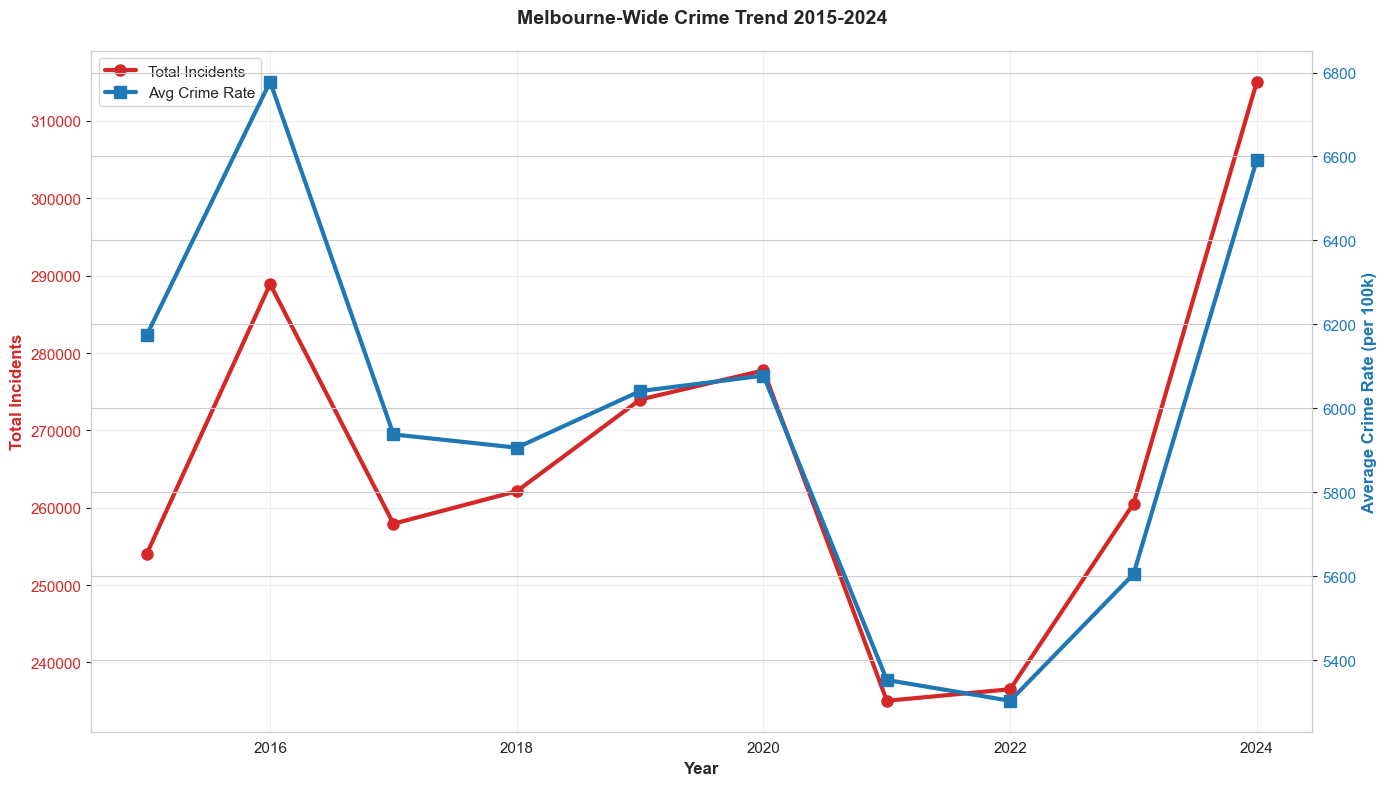


✓ What this shows:
  - Red line: Total incidents in Melbourne
  - Blue line: Average crime rate across all LGAs
  - Both lines going up = Melbourne getting more dangerous
  - Both lines going down = Melbourne getting safer

📊 Summary:
   2015 Total: 254,042 incidents
   2024 Total: 315,073 incidents
   Change: +24.02%
   ⚠️ Melbourne got MORE dangerous


In [23]:
# ==================================================================================
# ──  VISUALIZATION FOR QUERY 5 ──────────────────────────────────────
# ==================================================================================

print("\n" + "="*60)
print("VISUALIZATION: Melbourne-Wide Crime Trend (2015-2024)")
print("="*60)

# Create figure
fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot 1: Total Incidents (left y-axis)
color = 'tab:red'
ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Incidents', color=color, fontsize=12, fontweight='bold')
line1 = ax1.plot(df_query5['year'], df_query5['total_incidents'], 
                 color=color, marker='o', linewidth=3, markersize=8, label='Total Incidents')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Plot 2: Average Crime Rate (right y-axis)
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Average Crime Rate (per 100k)', color=color, fontsize=12, fontweight='bold')
line2 = ax2.plot(df_query5['year'], df_query5['avg_crime_rate'], 
                 color=color, marker='s', linewidth=3, markersize=8, label='Avg Crime Rate')
ax2.tick_params(axis='y', labelcolor=color)

# Title and legend
plt.title("Melbourne-Wide Crime Trend 2015-2024", 
          fontsize=14, fontweight='bold', pad=20)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=11)

plt.tight_layout()
# Save the chart
chart_path = VIZ_OUTPUT + "05_annual_trend_melbourne_wide.png"
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Chart saved: {chart_path}")

plt.show()

print("\n✓ What this shows:")
print("  - Red line: Total incidents in Melbourne")
print("  - Blue line: Average crime rate across all LGAs")
print("  - Both lines going up = Melbourne getting more dangerous")
print("  - Both lines going down = Melbourne getting safer")

# Show summary
print(f"\n📊 Summary:")
first_incidents = df_query5.iloc[0]['total_incidents']
last_incidents = df_query5.iloc[-1]['total_incidents']
change_pct = ((last_incidents - first_incidents) / first_incidents) * 100
print(f"   2015 Total: {first_incidents:,.0f} incidents")
print(f"   2024 Total: {last_incidents:,.0f} incidents")
print(f"   Change: {change_pct:+.2f}%")
if change_pct > 0:
    print(f"   ⚠️ Melbourne got MORE dangerous")
else:
    print(f"   ✅ Melbourne got SAFER")


In [24]:
# ==================================================================================
# ──  SUMMARY & VERIFICATION ────────────────────────────────────────────
# ==================================================================================

print("\n" + "="*60)
print("✅ PHASE 2 COMPLETE - SQL ANALYSIS + VISUALIZATIONS")
print("="*60)

print(f"\n📊 CSV Files Generated:\n")
csv_files = [
    "01_trend_by_lga_year.csv",
    "02_top10_highest_crime.csv",
    "03_top10_safest.csv",
    "04_2015_vs_2024_comparison.csv",
    "05_annual_trend_melbourne_wide.csv"
]

for i, filename in enumerate(csv_files, 1):
    filepath = SQL_OUTPUT + filename
    if os.path.exists(filepath):
        filesize = os.path.getsize(filepath) / 1024
        print(f"✓ {i}. {filename:<45} ({filesize:.2f} KB)")
    else:
        print(f"❌ {i}. {filename:<45} NOT FOUND")

print(f"\n📈 Visualization Charts Generated:\n")
viz_files = [
    "01_crime_trend_top5_lgas.png",
    "02_top10_highest_crime.png",
    "03_top10_safest.png",
    "04_2015_vs_2024_comparison.png",
    "05_annual_trend_melbourne_wide.png"
]
for i, filename in enumerate(viz_files, 1):
    filepath = VIZ_OUTPUT + filename
    if os.path.exists(filepath):
        filesize = os.path.getsize(filepath) / 1024
        print(f"✓ {i}. {filename:<45} ({filesize:.2f} KB)")
    else:
        print(f"❌ {i}. {filename:<45} NOT FOUND")

print(f"\n✅ Summary:")
print(f"   ✓ Created SQLite database: crime_data.db")
print(f"   ✓ Created 'crimes' table with {len(crime_df)} rows")
print(f"   ✓ Ran 5 SQL queries")
print(f"   ✓ Exported 5 CSV files")
print(f"   ✓ Generated 5 visualization charts (PNG)")

print(f"\n📂 Folder Structure:")
print(f"   sql/")
print(f"   ├── 01_trend_by_lga_year.csv")
print(f"   ├── 02_top10_highest_crime.csv")
print(f"   ├── 03_top10_safest.csv")
print(f"   ├── 04_2015_vs_2024_comparison.csv")
print(f"   ├── 05_annual_trend_melbourne_wide.csv")
print(f"   └── visualizations/")
print(f"       ├── 01_crime_trend_top5_lgas.png")
print(f"       ├── 02_top10_highest_crime.png")
print(f"       ├── 03_top10_safest.png")
print(f"       ├── 04_2015_vs_2024_comparison.png")
print(f"       └── 05_annual_trend_melbourne_wide.png")

print(f"\n🎨 Ready for Phase 3: Tableau Dashboard!")

print(f"\n✓ All CSVs ready to upload to Tableau")
print(f"✓ All charts ready to add to GitHub README")

# Close the database connection
conn.close()
print(f"\n✓ Database connection closed")

print(f"\n" + "="*60)
print(f"✅ PHASE 2 SUCCESSFULLY COMPLETED!")
print(f"="*60)


✅ PHASE 2 COMPLETE - SQL ANALYSIS + VISUALIZATIONS

📊 CSV Files Generated:

✓ 1. 01_trend_by_lga_year.csv                      (8.11 KB)
✓ 2. 02_top10_highest_crime.csv                    (0.41 KB)
✓ 3. 03_top10_safest.csv                           (0.41 KB)
✓ 4. 04_2015_vs_2024_comparison.csv                (0.90 KB)
✓ 5. 05_annual_trend_melbourne_wide.csv            (0.47 KB)

📈 Visualization Charts Generated:

✓ 1. 01_crime_trend_top5_lgas.png                  (347.31 KB)
✓ 2. 02_top10_highest_crime.png                    (178.67 KB)
✓ 3. 03_top10_safest.png                           (190.35 KB)
✓ 4. 04_2015_vs_2024_comparison.png                (718.40 KB)
✓ 5. 05_annual_trend_melbourne_wide.png            (384.57 KB)

✅ Summary:
   ✓ Created SQLite database: crime_data.db
   ✓ Created 'crimes' table with 290 rows
   ✓ Ran 5 SQL queries
   ✓ Exported 5 CSV files
   ✓ Generated 5 visualization charts (PNG)

📂 Folder Structure:
   sql/
   ├── 01_trend_by_lga_year.csv
   ├── 02_top10